# `mosaic(bounds=...)` — Sentinel-2 mosaics for arbitrary bounding boxes

Instead of passing an MGRS tile via `grid_id`, you can pass a `bounds` tuple to mosaic any rectangular area, including ones that intersect Sentinel-2 tiles in different UTM zone projections. Each intersecting scene is streamed through a rasterio `WarpedVRT` and aggregated onto a common UTM grid.

This notebook shows: a basic bounds call, a lower-resolution mosaic with bilinear resampling, a four-tile AOI that intersects scenes in two different UTM projections, and saving to disk.

In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

from s2mosaic import mosaic

## 1. Basic usage — small bounds in EPSG:4326

Bounds are `(minx, miny, maxx, maxy)`. Default `bounds_crs=4326`, so this is a lon/lat box. Output CRS is auto-picked from the bbox centroid (UTM zone 50S here).

In [2]:
# ~5km AOI near Perth, WA
bounds = (115.83, -31.97, 115.91, -31.94)

array, profile = mosaic(
    bounds=bounds,
    start_year=2023,
    start_month=6,
    start_day=1,
    duration_months=2,
    required_bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile=50,
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

Shape: (3, 340, 760)
CRS:   EPSG:32750
Pixel: 10.0m


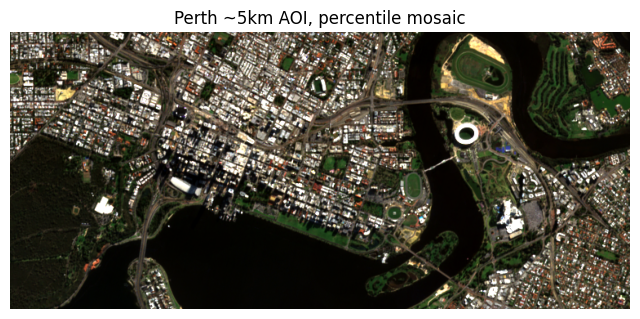

In [3]:
# Display as a stretched RGB composite (B04, B03, B02)
rgb = array.transpose(1, 2, 0).astype(float)
p2, p98 = np.percentile(rgb[rgb > 0], [2, 98])
rgb_clipped = ((rgb - p2) / (p98 - p2)).clip(0, 1)
plt.figure(figsize=(8, 6))
plt.imshow(rgb_clipped)
plt.title("Perth ~5km AOI, percentile mosaic")
plt.axis("off");

## 2. Lower resolution + bilinear resampling

`resolution` is in metres of the output pixel. At 30m, rasterio reads from the nearest COG overview rather than the native 10m file — much less data over the wire. `resampling_method` controls how the source is resampled; `bilinear` is appropriate for continuous reflectance data.

In [4]:
array, profile = mosaic(
    bounds=bounds,  # same Perth AOI as section 1
    start_year=2023,
    start_month=6,
    duration_days=14,
    required_bands=["B04", "B03", "B02"],
    mosaic_method="mean",
    resolution=30,
    resampling_method="bilinear",
    additional_query={"eo:cloud_cover": {"lt": 50}},
)

print(f"Shape: {array.shape}  (vs ~256x256 at 30m for ~5km AOI)")
print(f"Pixel size: {profile['transform'].a}m")

Shape: (3, 113, 253)  (vs ~256x256 at 30m for ~5km AOI)
Pixel size: 30.0m


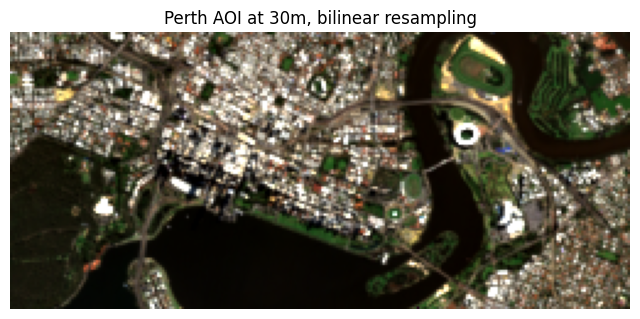

In [5]:
rgb = array.transpose(1, 2, 0).astype(float)
p2, p98 = np.percentile(rgb[rgb > 0], [2, 98])
rgb_clipped = ((rgb - p2) / (p98 - p2)).clip(0, 1)
plt.figure(figsize=(8, 8))
plt.imshow(rgb_clipped)
plt.title("Perth AOI at 30m, bilinear resampling")
plt.axis("off");

## 3. Four-tile AOI with mixed UTM projections

Sentinel-2 tile footprints overlap, so even a small AOI can be covered by scenes from several MGRS tiles — and those tiles can live in different UTM zones. The AOI below sits NW of Melbourne, at the corner where `54HYC`, `54HYD`, `55HBT` and `55HBU` all overlap: two of those tiles are in UTM zone 54, two in zone 55, so scenes arrive in two native projections (EPSG:32754 and EPSG:32755). Each scene is reprojected on read (via `WarpedVRT`) onto one common UTM grid (auto-picked from the bbox centroid) and the output is seamless.

In [6]:
cross_bounds = (144.422, -37.953, 144.462, -37.913)

array, profile = mosaic(
    bounds=cross_bounds,
    start_year=2023,
    start_month=1,
    duration_months=1,
    required_bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile=50,
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

Shape: (3, 454, 364)
CRS:   EPSG:32755
Pixel: 10.0m


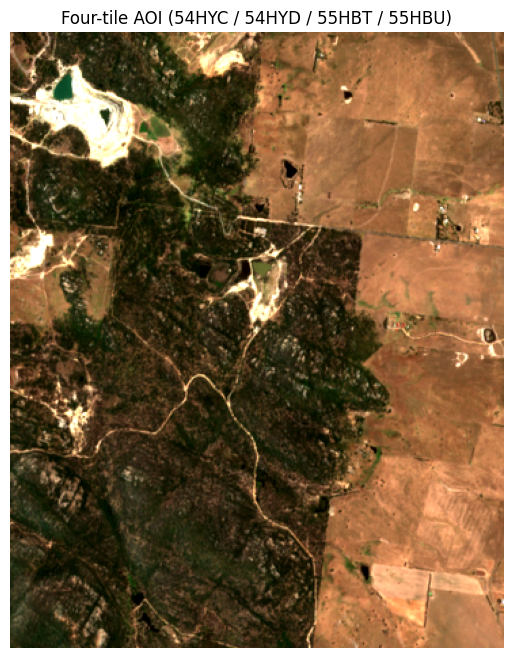

In [7]:
rgb = array.transpose(1, 2, 0).astype(float)
p2, p98 = np.percentile(rgb[rgb > 0], [2, 98])
rgb_clipped = ((rgb - p2) / (p98 - p2)).clip(0, 1)
plt.figure(figsize=(8, 8))
plt.imshow(rgb_clipped)
plt.title("Four-tile AOI (54HYC / 54HYD / 55HBT / 55HBU)")
plt.axis("off");

## 4. Save to disk

Pass `output_dir` and the GeoTIFF is written with an auto-generated filename. The filename uses the bbox coordinates instead of an MGRS tile ID.

In [8]:
result = mosaic(
    bounds=bounds,
    start_year=2023,
    start_month=6,
    duration_days=14,
    output_dir=Path("output"),
    required_bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile=50,
    additional_query={"eo:cloud_cover": {"lt": 50}},
)
print(f"Saved to: {result}")

Saved to: output/bounds_115.8300_-31.9700_115.9100_-31.9400_2023-06-01_to_2023-06-15_valid_data_percentile_p50_B04_B03_B02.tif
